
 

| **Nombre** : Benjamin Naranjo 
| **RUT** : 21687575-3 
| **Fecha** : 27-05-2026 



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


df = pd.read_csv('dataset_produccion_s13.csv')
print('Primeras 5 filas')
df.head()

Primeras 5 filas


,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
0,L001,Abrazadera D,Tarde,114,1.95,204.4,37.8,8.0,222.30
1,L002,Válvula E,Tarde,306,2.83,230.8,56.8,11.0,865.98
2,L003,Tuerca C,Tarde,180,3.66,242.8,44.8,4.0,658.80
3,L004,Válvula E,Tarde,210,2.14,242.1,38.5,0.0,449.40
4,L005,Válvula E,Tarde,336,4.87,234.6,14.9,9.0,1636.32


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_lote              60 non-null     object 
 1   producto             60 non-null     object 
 2   turno                60 non-null     object 
 3   unidades_producidas  60 non-null     int64  
 4   costo_unitario       59 non-null     float64
 5   temperatura_horno    59 non-null     float64
 6   tiempo_ciclo_min     60 non-null     float64
 7   defectos             59 non-null     float64
 8   costo_total          60 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 4.3+ KB


,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
count,60.000000,59.000000,59.000000,60.000000,59.000000,60.000000
mean,244.266667,2.664576,229.406780,35.813333,7.203390,656.710667
std,90.248408,1.297236,104.204605,15.335662,4.494363,407.032651
min,84.000000,0.570000,180.400000,-5.000000,0.000000,62.980000
25%,172.500000,1.590000,197.850000,24.600000,4.000000,338.775000
50%,250.500000,2.740000,219.800000,37.450000,7.000000,609.940000
75%,312.250000,3.580000,235.100000,48.825000,11.500000,894.045000
max,397.000000,4.940000,999.900000,59.500000,14.000000,1636.320000


In [3]:

nulos = df.isnull().sum()
print('Valores nulos por columna')
print(nulos)
print(f'\nColumnas con datos faltantes: {list(nulos[nulos > 0].index)}')

Valores nulos por columna
id_lote                0
producto               0
turno                  0
unidades_producidas    0
costo_unitario         1
temperatura_horno      1
tiempo_ciclo_min       0
defectos               1
costo_total            0
dtype: int64

Columnas con datos faltantes: ['costo_unitario', 'temperatura_horno', 'defectos']


In [4]:
# 1.4 Identificación de outliers con media ± 3σ
for col in ['temperatura_horno', 'tiempo_ciclo_min']:
    serie = df[col].dropna()
    media = serie.mean()
    sigma = serie.std()
    lim_inf = media - 3 * sigma
    lim_sup = media + 3 * sigma
    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)][col]
    print(f'{col}')
    print(f'  Media: {media:.2f} | σ: {sigma:.2f}')
    print(f'  Límite inferior: {lim_inf:.2f}')
    print(f'  Límite superior: {lim_sup:.2f}')
    print(f'  Outliers detectados: {len(outliers)}')
    if len(outliers) > 0:
        print(f'  Valores: {outliers.values}\n')
    else:
        print()

temperatura_horno
  Media: 229.41 | σ: 104.20
  Límite inferior: -83.21
  Límite superior: 542.02
  Outliers detectados: 1
  Valores: [999.9]

tiempo_ciclo_min
  Media: 35.81 | σ: 15.34
  Límite inferior: -10.19
  Límite superior: 81.82
  Outliers detectados: 0



Valor negativo en tiempo_ciclo_min

Un tiempo de ciclo negativo no tiene sentido físico. Dado que representa la duración que tarda el horno en completar un lote de producción, lo cual es una magnitud estrictamente positiva. Un valor negativo solo puede ser producto de un error de registro, un fallo en el sensor o un ingreso manual incorrecto. Este tipo de dato debe ser tratado como un error y eliminado o imputado.

In [5]:
# Estadísticas descriptivas de temperatura_horno (excluyendo nulos)
temp = df['temperatura_horno'].dropna()

print('Estadísticas de temperatura_horno ')
print(f'  Media    : {temp.mean():.2f} °C')
print(f'  Mediana  : {temp.median():.2f} °C')
print(f'  Desv. Est: {temp.std():.2f} °C')
print(f'  Mínimo   : {temp.min():.2f} °C')
print(f'  Máximo   : {temp.max():.2f} °C')

Estadísticas de temperatura_horno 
  Media    : 229.41 °C
  Mediana  : 219.80 °C
  Desv. Est: 104.20 °C
  Mínimo   : 180.40 °C
  Máximo   : 999.90 °C


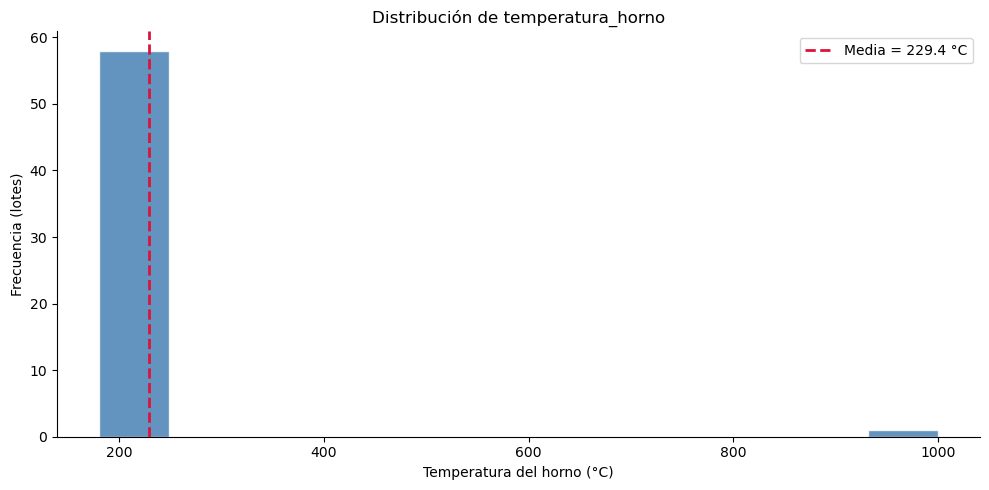

In [6]:
# Histograma de temperatura_horno con línea en la media
fig, ax = plt.subplots()
ax.hist(temp, bins=12, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(temp.mean(), color='crimson', linestyle='--', linewidth=2,
           label=f'Media = {temp.mean():.1f} °C')
ax.set_title('Distribución de temperatura_horno')
ax.set_xlabel('Temperatura del horno (°C)')
ax.set_ylabel('Frecuencia (lotes)')
ax.legend()
plt.tight_layout()
plt.show()

¿La distribución de temperatura parece uniforme o concentrada? ¿Qué implica eso para la función de costo?

La distribución de temperatura_horno se ve más concentrada que uniforme, porque la mayoría de los datos están cerca de la media y no repartidos por todo el rango. Esto muestra que la planta normalmente trabaja dentro de temperaturas bastante similares.

Para la función de costo, esto significa que la mayoría de los valores están cerca de la temperatura óptima. Por eso, el modelo cuadrático tiene sentido: si la temperatura se aleja un poco del valor ideal, el costo sube poco, pero si se aleja mucho, el costo aumenta bastante más.

In [7]:
# Parámetros del modelo
T_OPTIMA   = 220
COSTO_BASE = 1500

def costo_produccion(temperatura):
    """
    Modela el costo de produccion por lote en funcion de la temperatura del horno.

    Parametros:
        temperatura (float): temperatura del horno en grados Celsius
    Retorna:
        float: costo estimado del lote en pesos
    """
    return 0.05 * (temperatura - T_OPTIMA) ** 2 + COSTO_BASE

# Verificación: el mínimo debe ocurrir exactamente en T_OPTIMA
print(f'costo_produccion(220) = {costo_produccion(220):.2f}  | debe ser {COSTO_BASE}')

costo_produccion(220) = 1500.00  | debe ser 1500


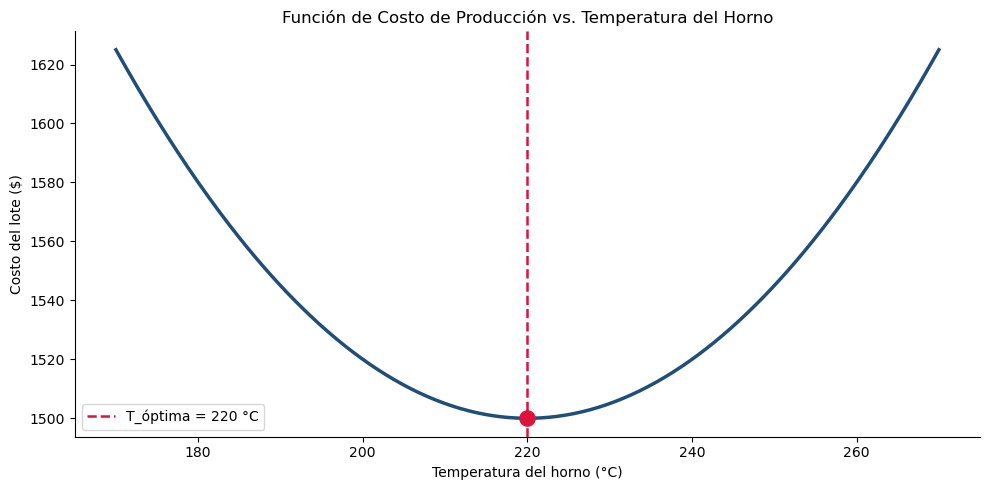

In [8]:
# Gráfico de la función de costo en [170, 270]
T_rango = np.linspace(170, 270, 400)
C_rango = [costo_produccion(t) for t in T_rango]

fig, ax = plt.subplots()
ax.plot(T_rango, C_rango, color='#1f4e79', lw=2.5)
ax.axvline(T_OPTIMA, color='crimson', ls='--', lw=1.8, label=f'T_óptima = {T_OPTIMA} °C')
ax.scatter([T_OPTIMA], [COSTO_BASE], color='crimson', s=120, zorder=5)
ax.set_title('Función de Costo de Producción vs. Temperatura del Horno')
ax.set_xlabel('Temperatura del horno (°C)')
ax.set_ylabel('Costo del lote ($)')
ax.legend()
plt.tight_layout()
plt.show()

Observa el gráfico: ¿es la función unimodal? ¿Tiene sentido aplicar minimize_scalar
directamente?

Si es la función unimodal, ya que es una función parabolica con un unico valor minimo. Esto es exactamente el tipo de función que minimize_scalar puede resolver de forma eficiente y garantizada. Sí tiene sentido aplicarlo directamente, ya que no existe riesgo de quedarse atrapado en un mínimo local.

In [9]:
# Aplicar minimize_scalar con método Brent 
resultado_brent = minimize_scalar(costo_produccion, method='brent')

if resultado_brent.success:
    print('El método Brent se verificó exitosamente.')
    print(f'  resultado.x       = {resultado_brent.x:.2f} °C  | temperatura óptima')
    print(f'  resultado.fun     = {resultado_brent.fun:.2f} $ | costo mínimo')
    print(f'  resultado.success = {resultado_brent.success}')
    print(f'  resultado.nit     = {resultado_brent.nit} | iteraciones')
else:
    print('')

El método Brent se verificó exitosamente.
  resultado.x       = 220.00 °C  | temperatura óptima
  resultado.fun     = 1500.00 $ | costo mínimo
  resultado.success = True
  resultado.nit     = 4 | iteraciones


¿la temperatura óptima hallada coincide con tu T_optima
definida? ¿Por qué o por qué no?


La temperatura óptima hallada por Brent coincide con T_optima = 220 °C. Esto es esperado porque la función es una parábola con un único mínimo analítico en 220 °C, y el método Brent es un algoritmo de búsqueda de raíces o mínimos de una función.

In [10]:
# Aplicar minimize_scalar con restricción de dominio operativo
resultado_bounded = minimize_scalar(
    costo_produccion,
    bounds=(180, 250),
    method='bounded'
)

if resultado_bounded.success:
    print(' El método Bounded se verificó exitosamente.')
    print(f'  resultado.x       = {resultado_bounded.x:.2f} °C')
    print(f'  resultado.fun     = {resultado_bounded.fun:.2f} $')
    print(f'  resultado.success = {resultado_bounded.success}')
    print(f'  resultado.nit     = {resultado_bounded.nit}')
else:
    print('')

# Comparación directa
print('\n Comparación de resultados ')
print(f'  Brent   x = {resultado_brent.x:.2f} °C')
print(f'  Bounded x = {resultado_bounded.x:.2f} °C ')


 El método Bounded se verificó exitosamente.
  resultado.x       = 220.00 °C
  resultado.fun     = 1500.00 $
  resultado.success = True
  resultado.nit     = 6

 Comparación de resultados 
  Brent   x = 220.00 °C
  Bounded x = 220.00 °C 


Compara resultado_brent.x con resultado_bounded.x. ¿Son iguales? ¿Cuál prefieres
y por qué?


Sí, en este caso particular ambos métodos encuentran 220 °C como temperatura óptima, porque ese valor se encuentra dentro del intervalo [180, 250]. 
 En un contexto industrial, prefiero bounded, porque garantiza que la solución sea físicamente realizable. Operar el horno a una temperatura fuera del rango seguro podría dañar el equipo o generar productos defectuosos, independientemente de lo que el modelo matemático sugiera.



In [11]:
comparacion = pd.DataFrame({
    'Metodo'     : ['brent', 'bounded'],
    'x_optimo'   : [resultado_brent.x,   resultado_bounded.x],
    'costo_min'  : [resultado_brent.fun,  resultado_bounded.fun],
    'iteraciones': [resultado_brent.nit,  resultado_bounded.nit],
    'convergio'  : [resultado_brent.success, resultado_bounded.success]
})

print(' Tabla Comparativa')
print(comparacion.to_string(index=False))

 Tabla Comparativa
 Metodo  x_optimo  costo_min  iteraciones  convergio
  brent     220.0     1500.0            4       True
bounded     220.0     1500.0            6       True


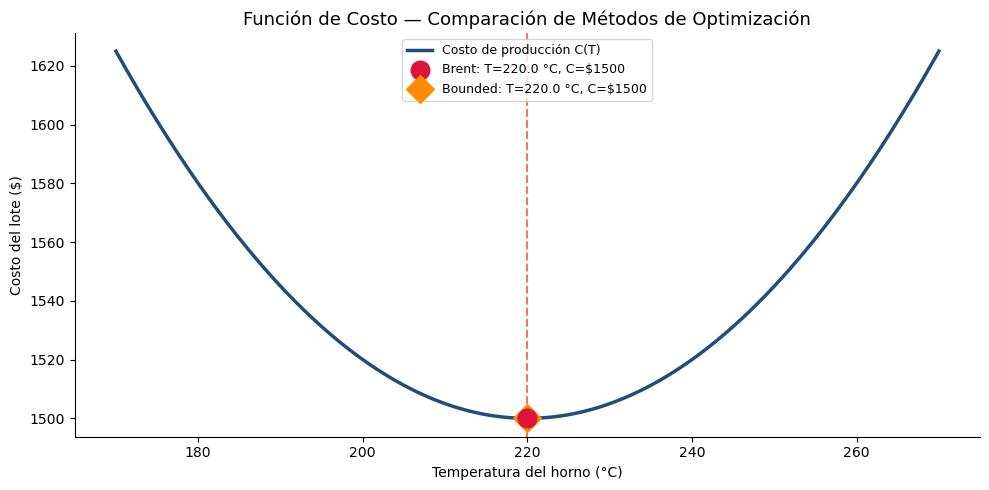

In [12]:
T_viz = np.linspace(170, 270, 400)
C_viz = [costo_produccion(t) for t in T_viz]

fig, ax = plt.subplots(figsize=(10, 5))

# Función de costo
ax.plot(T_viz, C_viz, color='#1f4e79', lw=2.5, label='Costo de producción C(T)')



ax.scatter([resultado_brent.x], [resultado_brent.fun],
           color='crimson', s=180, zorder=6, marker='o',
           label=f"Brent: T={resultado_brent.x:.1f} °C, C=${resultado_brent.fun:.0f}")
ax.axvline(resultado_brent.x, color='crimson', ls='--', lw=1.5, alpha=0.6)

ax.scatter([resultado_bounded.x], [resultado_bounded.fun],
           color='darkorange', s=200, zorder=5, marker='D',
           label=f"Bounded: T={resultado_bounded.x:.1f} °C, C=${resultado_bounded.fun:.0f}")
ax.axvline(resultado_bounded.x, color='darkorange', ls=':', lw=1.5, alpha=0.6)
ax.set_title('Función de Costo — Comparación de Métodos de Optimización', fontsize=13)
ax.set_xlabel('Temperatura del horno (°C)')
ax.set_ylabel('Costo del lote ($)')
ax.legend(loc='upper center', fontsize=9)
plt.tight_layout()
plt.show()


¿Qué ventaja práctica ofrece el argumento bounds en un contexto industrial real?

En la industria, los equipos tienen rangos operativos definidos por seguridad, normativa y vida útil. Un optimizador sin restricciones podría sugerir temperaturas técnicamente óptimas desde el punto de vista del modelo matemático, pero físicamente inaceptables. Bounds permite incorporar esto de manera fisica, garantizando que la solución entregada sea siempre implementable en la planta real, sin necesidad de una etapa de postprocesamiento.

¿Qué ocurriría si definimos una función de costo con múltiples mínimos locales? ¿minimize_scalar sería suficiente?**

minimize_scalar no sería suficiente ante múltiples mínimos locales. Este algoritmo está diseñado para funciones unimodales: asume que existe un único mínimo en el intervalo de búsqueda y puede quedar atrapado en el primero que encuentre, sin garantía de que sea el global. Para funciones multimodales se requieren algoritmos de optimización global.

¿Cómo cambiarías la función de costo si el efecto de la temperatura fuera asimétrico?**

Si el costo crece más rápido a temperaturas bajas que a temperaturas altas , la parábola simétrica deja de ser válida. Una alternativa sería usar una función asimétrica por tramos
